# Employee Attrition Prediction Notebook

This notebook performs data analysis, preprocessing, and model training for predicting employee attrition.

In [70]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score , recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings

warnings.filterwarnings("ignore")

In [42]:
# Load Data
df = pd.read_csv("../data/data-693fc2b180037028972686.csv")
df.head(5)

df_clean = df.copy()

## Data Analysis and Preparation

In [43]:
# Shape
df_clean.shape

(1470, 35)

In [44]:
# Info
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [45]:
# Describe
for column in df_clean.columns:
    print(f"--- Statistics for column: {column} ---")
    print(df_clean[column].describe())
    print("-" * 30)

--- Statistics for column: Age ---
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64
------------------------------
--- Statistics for column: Attrition ---
count     1470
unique       2
top         No
freq      1233
Name: Attrition, dtype: object
------------------------------
--- Statistics for column: BusinessTravel ---
count              1470
unique                3
top       Travel_Rarely
freq               1043
Name: BusinessTravel, dtype: object
------------------------------
--- Statistics for column: DailyRate ---
count    1470.000000
mean      802.485714
std       403.509100
min       102.000000
25%       465.000000
50%       802.000000
75%      1157.000000
max      1499.000000
Name: DailyRate, dtype: float64
------------------------------
--- Statistics for column: Department ---
count                       1470
unique               

In [46]:
# Missing Values
df_clean.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [47]:
# Duplicated Values
df_clean.duplicated().sum()

0

In [48]:
# Encode Target
le = LabelEncoder()
df_clean['Attrition'] = le.fit_transform(df_clean['Attrition'])
df_clean.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


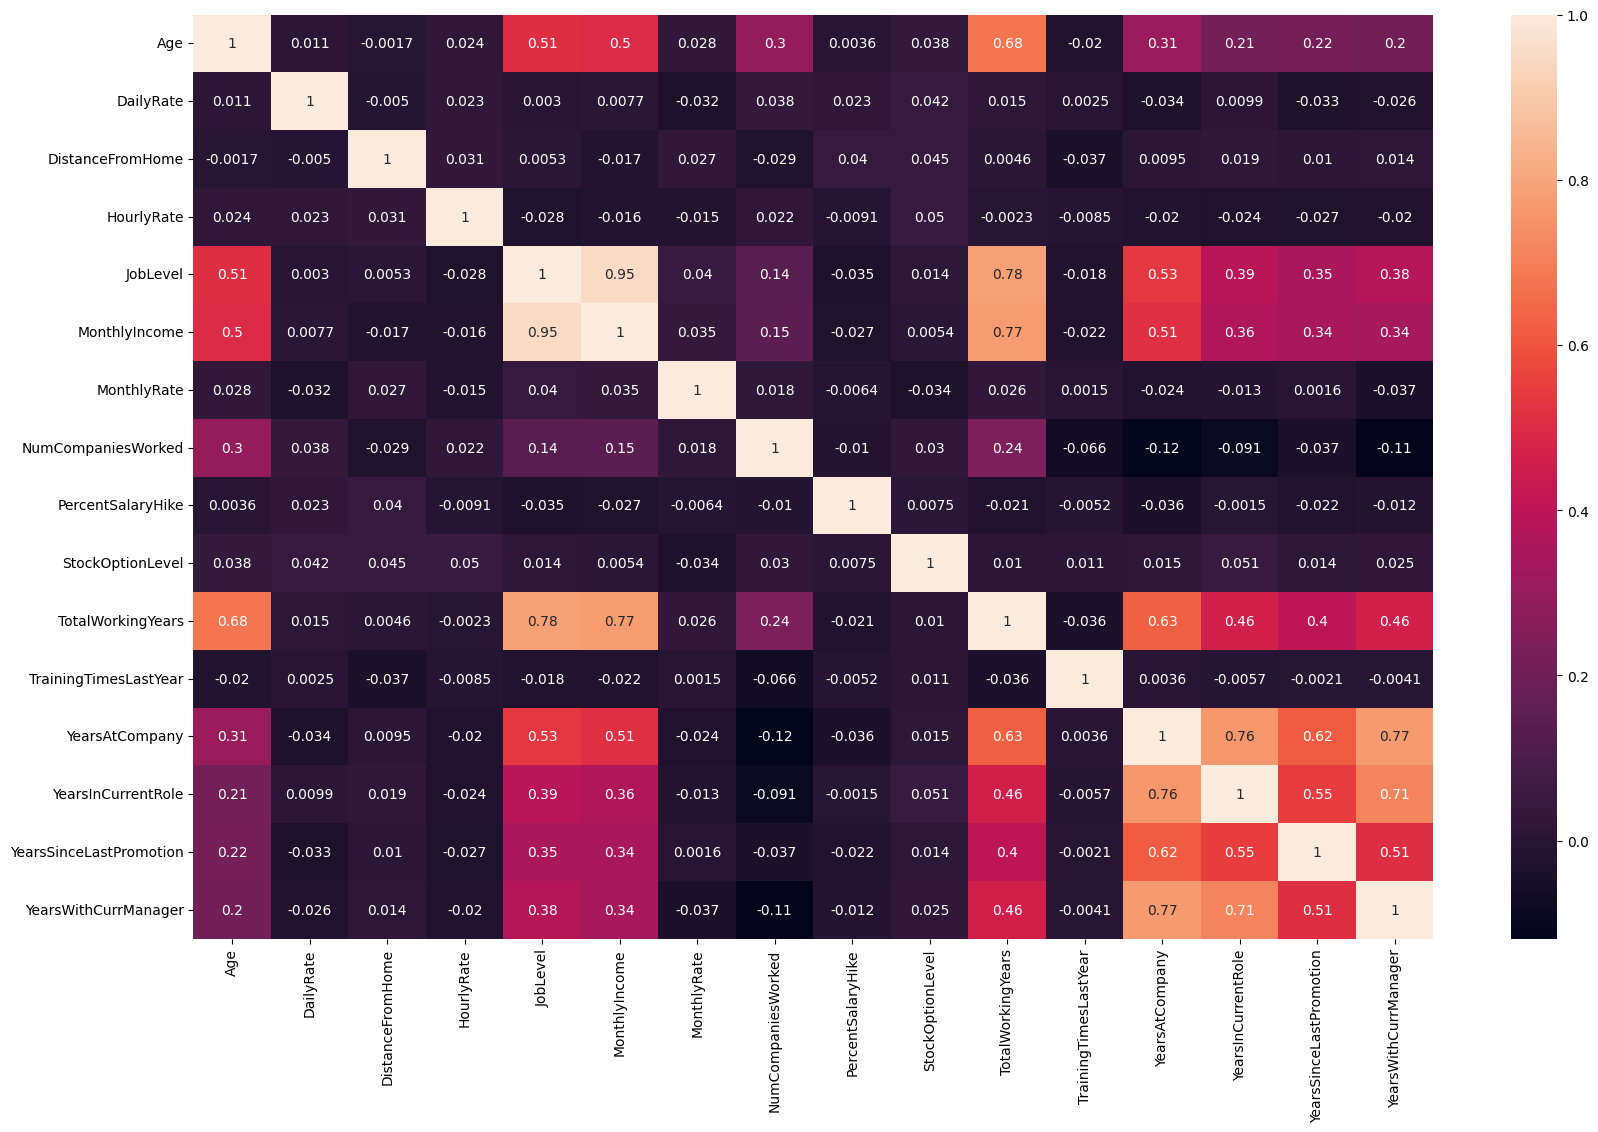

In [49]:
# Correlation
columns_to_drop_corr = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'WorkLifeBalance', 'RelationshipSatisfaction', 'PerformanceRating', 'JobSatisfaction', 'JobInvolvement', 'EnvironmentSatisfaction', 'Education']
numerical_df = df_clean.select_dtypes(include=['int64', 'float64'])
numerical_df = numerical_df.drop(columns=columns_to_drop_corr, axis=1)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

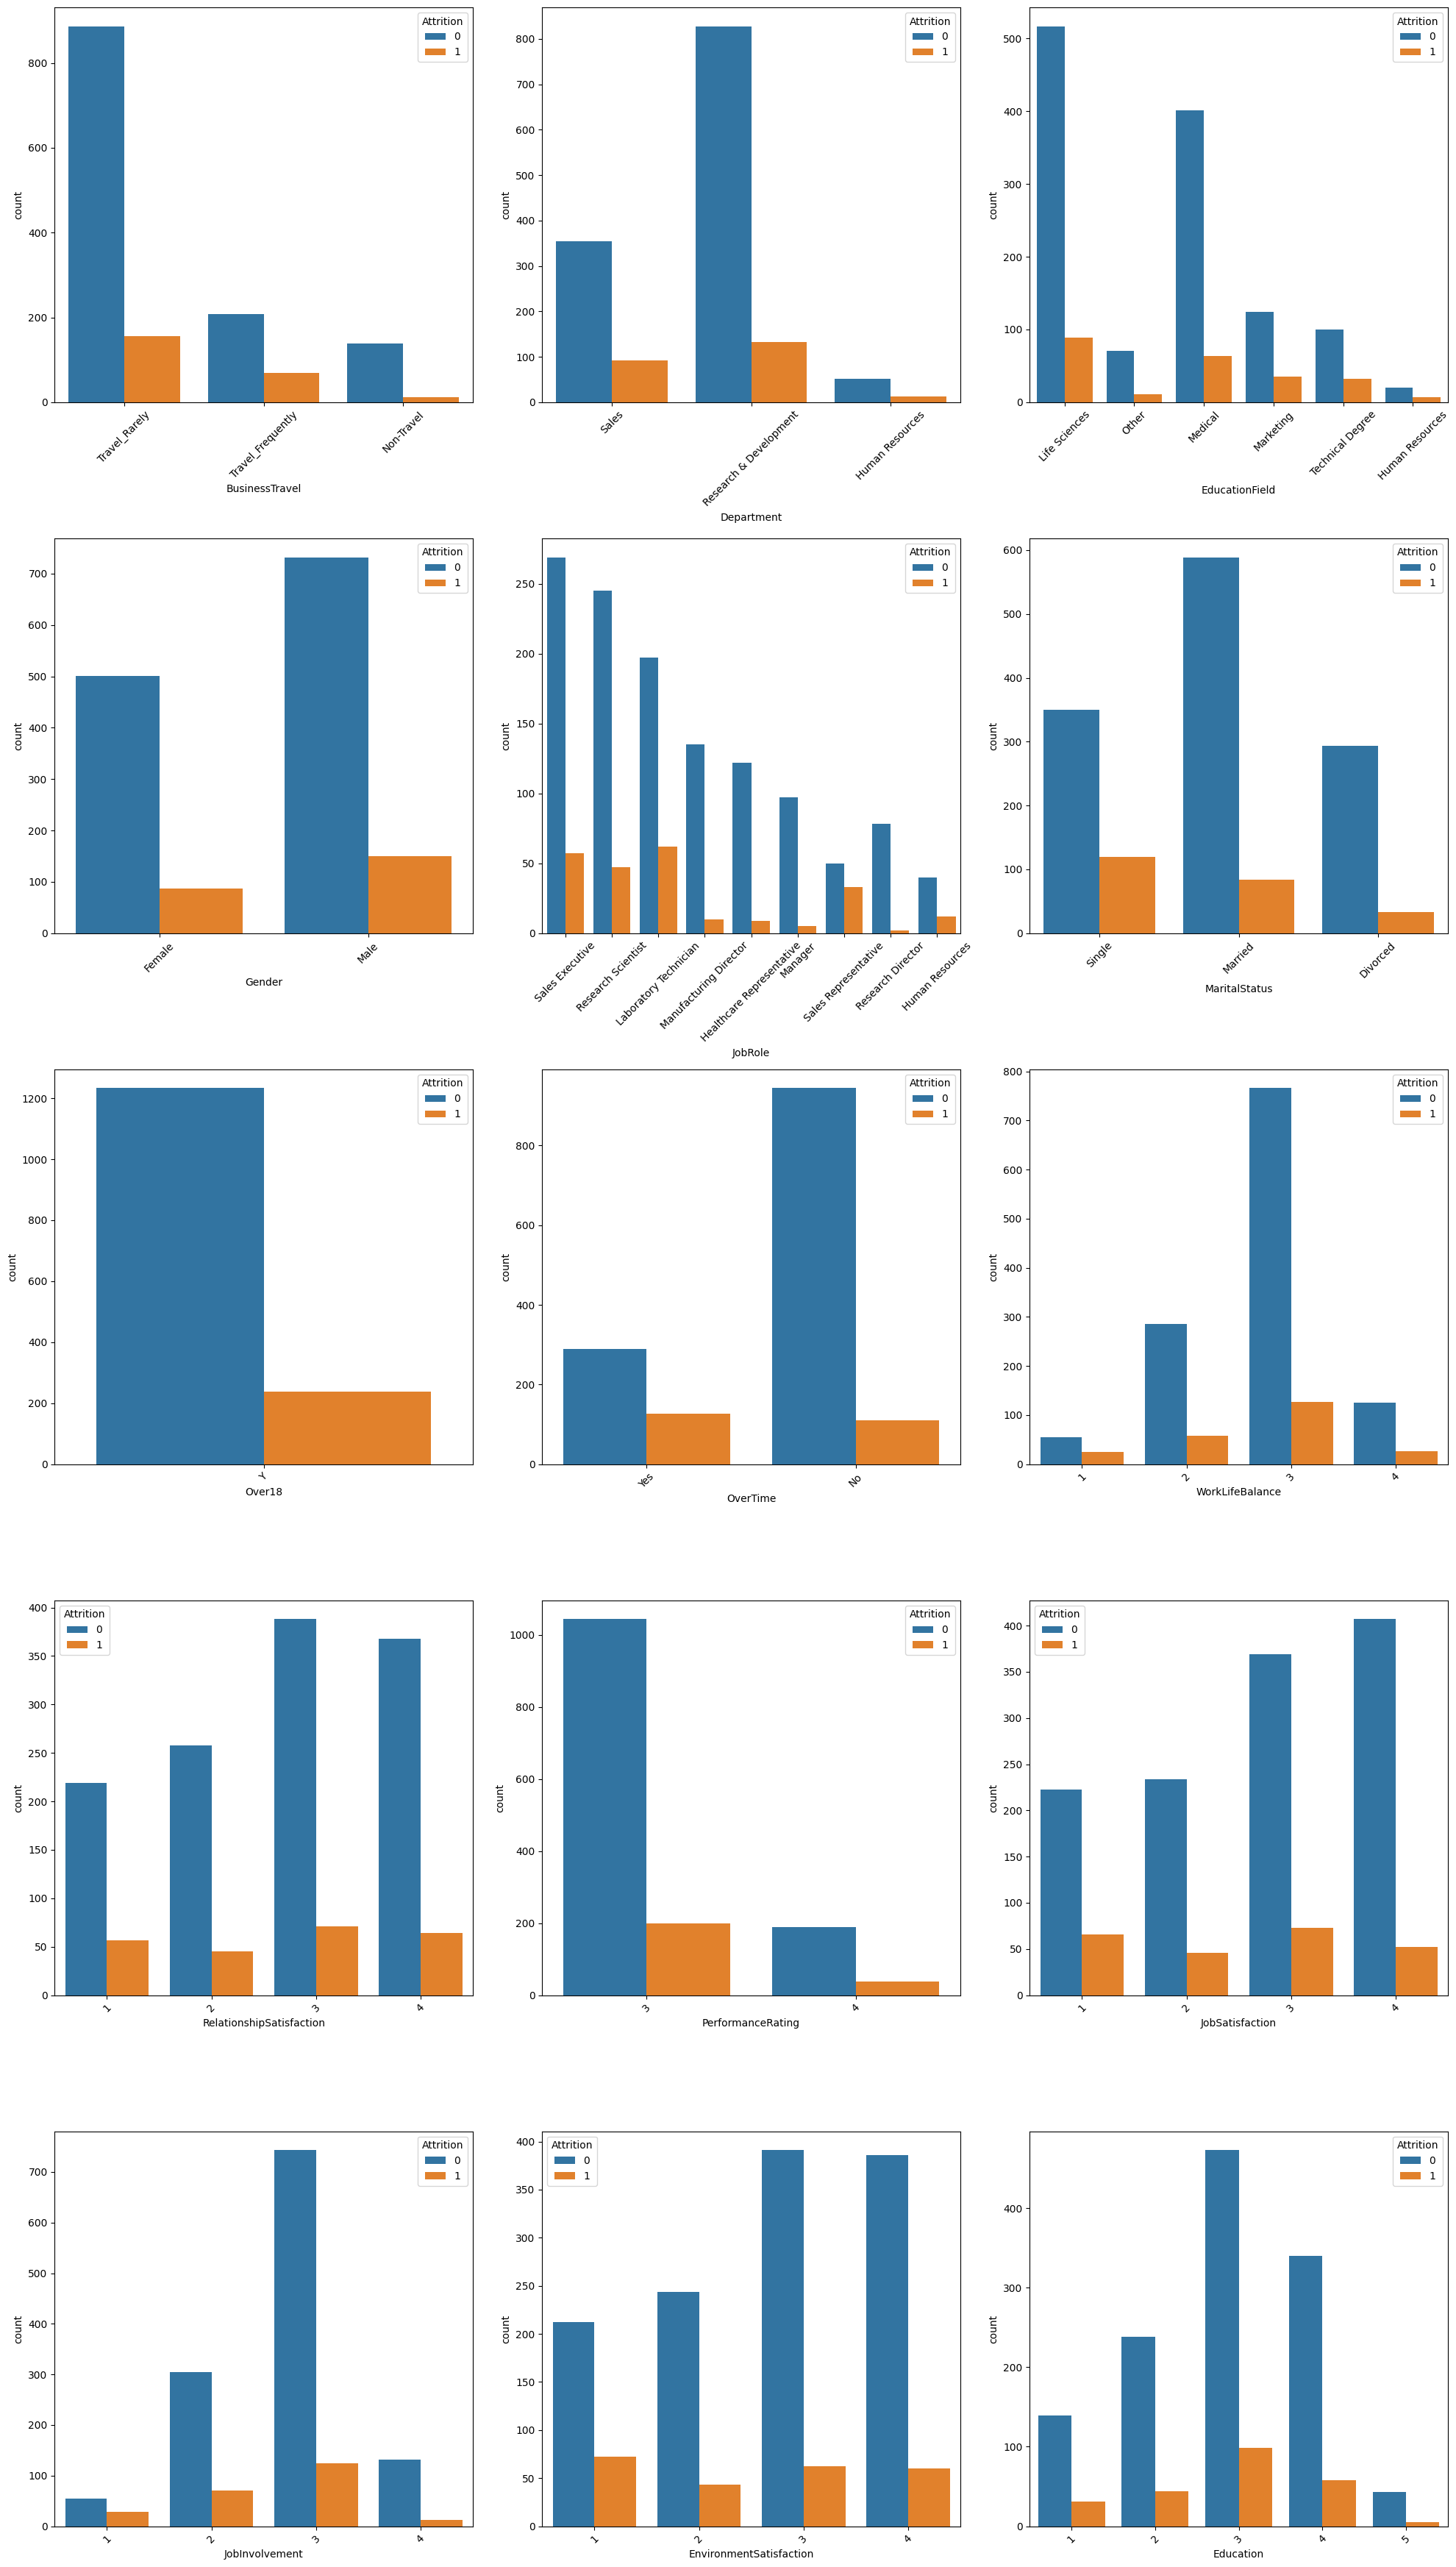

In [50]:
# Countplot
categorical_df = df_clean.select_dtypes(include=['object'])
fake_num = df_clean[['WorkLifeBalance', 'RelationshipSatisfaction', 'PerformanceRating', 'JobSatisfaction', 'JobInvolvement', 'EnvironmentSatisfaction', 'Education']]
new_categorical_df = pd.concat([categorical_df, fake_num], axis=1)

plt.figure(figsize=(20, 35))
i = 1
for col in new_categorical_df.columns:
    plt.subplot(5, 3, i)
    sns.countplot(data=df_clean, x=col, hue='Attrition')
    plt.xticks(rotation=45)
    i += 1
plt.tight_layout()
plt.show()

In [51]:
# Drop Unnecessary Columns
columns_to_drop = ['Gender', 'Over18', 'DistanceFromHome', 'MonthlyRate', 'HourlyRate', 'DailyRate', 'EmployeeNumber', 'StandardHours', 'EmployeeCount', 'StockOptionLevel', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'TrainingTimesLastYear', 'YearsSinceLastPromotion']
df_clean = df.drop(columns_to_drop, axis=1)
df_clean.shape

(1470, 20)

## Preprocessing

In [52]:
# Prepare Features and Target
features = df.drop(['Attrition'] + columns_to_drop, axis=1)
target = pd.DataFrame(le.fit_transform(df['Attrition']))
features.head(5)

,Age,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PerformanceRating,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,41,Travel_Rarely,Sales,2,Life Sciences,2,3,2,Sales Executive,4,Single,5993,Yes,3,8,1,6,4,5
1,49,Travel_Frequently,Research & Development,1,Life Sciences,3,2,2,Research Scientist,2,Married,5130,No,4,10,3,10,7,7
2,37,Travel_Rarely,Research & Development,2,Other,4,2,1,Laboratory Technician,3,Single,2090,Yes,3,7,3,0,0,0
3,33,Travel_Frequently,Research & Development,4,Life Sciences,4,3,1,Research Scientist,3,Married,2909,Yes,3,8,3,8,7,0
4,27,Travel_Rarely,Research & Development,1,Medical,1,3,1,Laboratory Technician,2,Married,3468,No,3,6,3,2,2,2


In [53]:
# Encode Categorical Features
categorical_features = features.select_dtypes(include='object')
numerical_features = features.select_dtypes(exclude='object')

encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded = pd.DataFrame(
    encoder.fit_transform(categorical_features),
    columns=encoder.get_feature_names_out(categorical_features.columns),
    index=features.index
)

features_final = pd.concat([numerical_features, categorical_encoded], axis=1)
features_final.head(5)

,Age,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,PerformanceRating,TotalWorkingYears,WorkLifeBalance,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,2,2,3,2,4,5993,3,8,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,49,1,3,2,2,2,5130,4,10,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,37,2,4,2,1,3,2090,3,7,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,33,4,4,3,1,3,2909,3,8,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,27,1,1,3,1,2,3468,3,6,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [54]:
# Scaling
std_columns = ['Age', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']
norm_columns = ['MonthlyIncome']

scaler_std = StandardScaler()
scaler_norm = MinMaxScaler()

features_final[std_columns] = scaler_std.fit_transform(features_final[std_columns])
features_final[norm_columns] = scaler_norm.fit_transform(features_final[norm_columns])

features_final.head()

,Age,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,PerformanceRating,TotalWorkingYears,WorkLifeBalance,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,2,2,3,2,4,0.262454,3,-0.421642,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,1.322365,1,3,2,2,2,0.217009,4,-0.164511,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.008343,2,4,2,1,3,0.056925,3,-0.550208,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,-0.429664,4,4,3,1,3,0.100053,3,-0.421642,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,-1.086676,1,1,3,1,2,0.129489,3,-0.678774,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Training and Evaluation

In [55]:
# Train-Test Split
X = features_final
y = target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Random Forest Accuracy: 0.8321995464852607
Random Forest F1: 0.1956521739130435
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       370
           1       0.43      0.13      0.20        71

    accuracy                           0.83       441
   macro avg       0.64      0.55      0.55       441
weighted avg       0.78      0.83      0.79       441



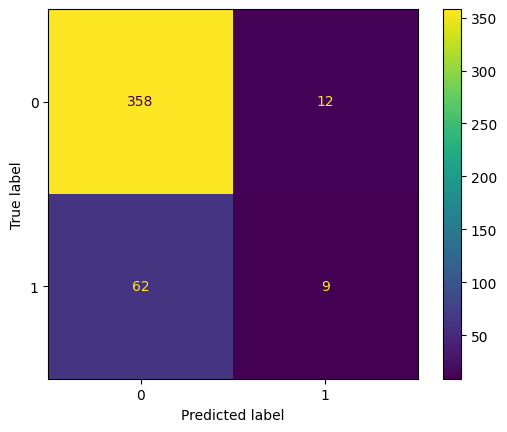

In [56]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.show()

Logistic Regression Accuracy: 0.8820861678004536
Logistic Regression F1: 0.49019607843137253
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       370
           1       0.81      0.35      0.49        71

    accuracy                           0.88       441
   macro avg       0.85      0.67      0.71       441
weighted avg       0.87      0.88      0.86       441



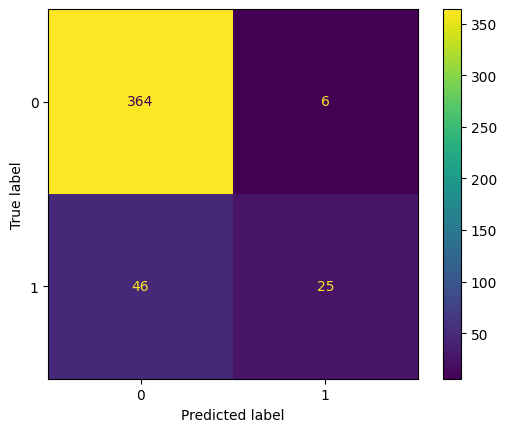

In [57]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.show()

## Grid Search

In [58]:
# Define Models and Parameters
models = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [None, 10, 20],
            'min_samples_leaf': [1, 2, 5]
        },
        'scoring': 'f1'
    },
    'LogisticRegression': {
        'model': LogisticRegression(),
        'params': {
            'C': [0.1, 1, 10, 15, 20],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']
        },
        'scoring': 'f1'
    },
    'SVC': {
        'model': SVC(),
        'params': {
            'C': [0.1, 1, 10, 15, 20],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        },
        'scoring': 'f1'
    }
}

# Perform Grid Search
results = {}
for name, config in models.items():
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring=config['scoring'],
        cv=5,
        n_jobs=1
    )
    grid.fit(X_train, y_train)
    results[name] = grid.best_score_
    print(f"{name}: Best params {grid.best_params_}")
    print(f"{name}: Best score {grid.best_score_:.4f}")

best_model = max(results, key=results.get)
best_score = results[best_model]
print(f"\nBest Model: {best_model} with score {best_score:.4f}")

RandomForest: Best params {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 500}
RandomForest: Best score 0.3449
LogisticRegression: Best params {'C': 10, 'penalty': 'l2', 'solver': 'sag'}
LogisticRegression: Best score 0.4741
SVC: Best params {'C': 15, 'gamma': 'auto', 'kernel': 'rbf'}
SVC: Best score 0.4970

Best Model: SVC with score 0.4970


## Pipeline

In [59]:
# Define and Fit Pipeline
pipeline = Pipeline(steps=[
    ('classifier', LogisticRegression(C=15, penalty='l2', solver='lbfgs'))
])

pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)

accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
f1_pipeline = f1_score(y_test, y_pred_pipeline)

print(f"Pipeline Accuracy: {accuracy_pipeline}")
print(f"Pipeline F1: {f1_pipeline}")

Pipeline Accuracy: 0.873015873015873
Pipeline F1: 0.48148148148148145


### Pipeline For Model saved :

In [71]:
numeric_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = features.select_dtypes(include=['object']).columns.tolist()
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) 

features_to_exclude_from_onehot = [
    'WorkLifeBalance', 'RelationshipSatisfaction', 'PerformanceRating',
    'JobSatisfaction', 'JobInvolvement', 'EnvironmentSatisfaction', 'Education'
]

numeric_features_for_standardization = []
for i in numeric_features:
    if i not in features_to_exclude_from_onehot:
        numeric_features_for_standardization.append(i)

print(numeric_features_for_standardization)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_for_standardization),
        ('cat', onehot_encoder, categorical_features)
    ],
    remainder='passthrough'
)

pipeline_final = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(probability=True, kernel='linear', random_state=42))
])


if len(features) != len(y):
    raise ValueError(f"Features and y have inconsistent numbers of samples: {len(features)} and {len(y)}")

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(features, y, test_size=0.2, random_state=42, stratify=y)

pipeline_final.fit(X_train_3, y_train_3)

y_pred_3 = pipeline_final.predict(X_test_3)
print(f"Accuracy: {accuracy_score(y_test_3, y_pred_3)}")
print(f"Recall: {recall_score(y_test_3, y_pred_3)}")
print(f"F1 Score: {f1_score(y_test_3, y_pred_3)}")


['Age', 'JobLevel', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']
Accuracy: 0.7551020408163265
Recall: 0.5957446808510638
F1 Score: 0.4375


## Save Model

In [61]:
# Save and Load Model
filename = "../model/Model.pkl"
joblib.dump(pipeline_final, filename)

['../model/Model.pkl']

## Test Model 

In [62]:
import pandas as pd
import joblib

Fake_Data = pd.DataFrame([{
    'Age': 29,
    'BusinessTravel': 'Travel_Rarely',
    'Department': 'Research & Development',
    'Education': 1,
    'EducationField': 'Life Sciences',
    'EnvironmentSatisfaction': 2,
    'JobInvolvement': 2,
    'JobLevel': 2,
    'JobRole': 'Research Scientist',
    'JobSatisfaction': 2,
    'MaritalStatus': 'Single',
    'MonthlyIncome': 5994,
    'OverTime': 'No',
    'PerformanceRating': 3,
    'TotalWorkingYears': 3,
    'TrainingTimesLastYear': 0,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 3,
    'YearsInCurrentRole': 3,
    'YearsWithCurrManager': 3
}])

model = joblib.load('../model/Model.pkl')

y_pred = model.predict(Fake_Data)
pd.DataFrame(y_pred)

,0
0,1
